<a href="https://colab.research.google.com/github/danish-khan962/ADGIPS-LabFiles/blob/main/ADL_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ADVANCES IN DEEP LEARNING LAB FILE**

In [1]:
# Global import of tensorflow
import tensorflow as tf

##**EXPERIMENT-01**
---
#####**Aim**: *Implement multilayer perceptron algorithm for MNIST Hand written Digit Classification.*
---
#####**Theory:** A multilayer perceptron (MLP) is a feedforward neural network with input, hidden, and output layers. It learns using backpropagation and updates weights using gradient descent.
######Loss is minimized using: `L=−∑ylog(y^​)`
---

#####**Code:**

In [2]:
# Importing dependencies
import tensorflow as tf
from tensorflow.keras import layers, models

In [3]:
# Loading the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [4]:
# Normalize data
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
# Flatten Images
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

In [6]:
# Building the base model
model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compiling the model
model.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

# Training the model
history = model.fit(x_train, y_train, epochs=5, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9309 - loss: 0.2388
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9681 - loss: 0.1038
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9771 - loss: 0.0735
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9828 - loss: 0.0545
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9861 - loss: 0.0435


In [7]:

# Evaluating the model
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy: ", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9741 - loss: 0.0880
Test Accuracy:  0.9740999937057495


<Axes: >

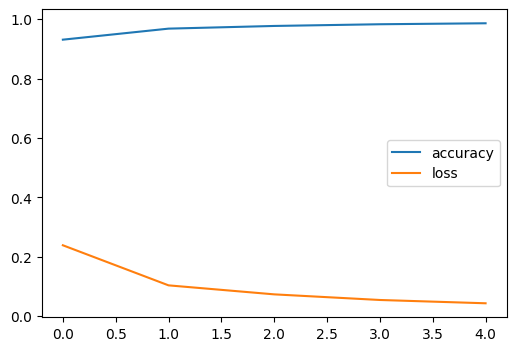

In [8]:
# Plotting the loss curve
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(6,4))

#####**Learning Outcomes:**
* Learned how MLP works for image classification.
* Understood preprocessing and model training steps.
* Gained knowledge of neural network layers and accuracy evaluation.
---

##**EXPERIMENT-02**
---
#####**Aim**: *Design a neural network for classifying movie reviews (Binary Classification) using IMDB dataset.*
---
#####**Theory:** Binary classification predicts output as 0 or 1 using sigmoid activation. Neural network learns by minimizing binary cross-entropy loss.
#####oss is minimized using: `L=−[ylog(y^​)+(1−y)log(1−y^​)]`
---

#####**Code:**

In [12]:
# Importing Dependencies
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [13]:
# Loading the dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
# Pad sequences
x_train = pad_sequences(x_train, maxlen=200)
x_test = pad_sequences(x_test, maxlen=200)

In [15]:
# Building the base model
model = models.Sequential([
    layers.Embedding(10000, 128, input_length=200),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compiling the model
model.compile(loss = tf.keras.losses.BinaryCrossentropy(),
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

# Training the model
history = model.fit(x_train, y_train, epochs=5, verbose=1)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 71ms/step - accuracy: 0.8158 - loss: 0.3868
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.9802 - loss: 0.0578
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - accuracy: 0.9961 - loss: 0.0120
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.9975 - loss: 0.0080
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - accuracy: 0.9926 - loss: 0.0215


782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8360 - loss: 0.8174
Test Accuracy: 0.8360000252723694


<Axes: >

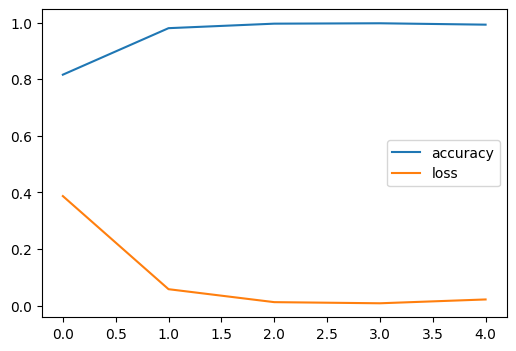

In [17]:
# Evaluating the model
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

# Plotting the loss curve
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(6,4))


#####**Learning Outcomes:**
* Learned binary classification using neural networks.
* Understood text preprocessing using padding.
* Gained knowledge of sigmoid activation and binary loss.
---

##**EXPERIMENT-03**
---
#####**Aim**: *Design a neural network for classifying news wires (Multi class classification) using Reuters dataset.*
---
#####**Theory:** Multi-class classification predicts one class among many using softmax activation.Neural network minimizes categorical cross-entropy loss during training.
######Loss is minimized using: `L=−∑yi​log(y^​i​)`
---

#####**Code:**

In [18]:
# Importing dependencies
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [19]:
# Loading the dataset
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=10000)

# Pad sequences
x_train = pad_sequences(x_train, maxlen=200)
x_test = pad_sequences(x_test, maxlen=200)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:
# Building the base model
model = models.Sequential([
    layers.Embedding(10000, 128, input_length=200),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(46, activation='softmax')
])

# Compiling the model
model.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

# Training the model
history = model.fit(x_train, y_train, epochs=5, verbose=1)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


281/281 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - accuracy: 0.5945 - loss: 1.6554
Epoch 2/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.8568 - loss: 0.6318
Epoch 3/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 25s 87ms/step - accuracy: 0.9466 - loss: 0.2670
Epoch 4/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 22s 79ms/step - accuracy: 0.9526 - loss: 0.1851
Epoch 5/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.9501 - loss: 0.1624


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6955 - loss: 1.4120
Test Accuracy:  0.6954585909843445


<Axes: >

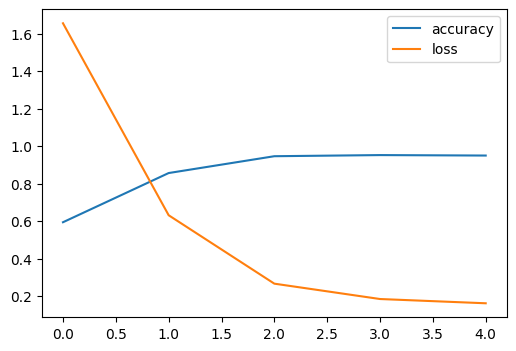

In [21]:
# Evaluating the model
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy: ", acc)

# Plotting the loss curve
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(6,4))

#####**Learning Outcomes:**
* Learned multi-class classification using neural networks.
* Understood softmax activation and categorical loss.
---